# Bertrand MFG Limit Order Book
## Ma-Noh HJB with Rank Coupling and Endogenous Ask Price

---

**Architecture.** Two nested layers:
- **Inner (per price level $a$):** Ma-Noh HJB-KFE on quantile grid with rank-dependent intensities $\Psi(u)$, $\Theta(u)$
- **Outer (Bertrand):** Each LP type $r_k$ chooses $a^*(r_k) = \arg\max_a J(r_k, a)$ where $J$ is the stationary average profit rate

## §1. Model

**Buyers.** Poisson($\alpha$), $v \sim F = \text{Uniform}[0,1]$, buy if $v \ge a$. Flow: $\phi(a) = \alpha(1-a)$.

**LPs.** Mass $N_{LP}$, $r_i \sim G = \text{Uniform}[r_{\min}, r_{\max}]$. Decisions: ask $a_i$ (Bertrand) + intensity $l_i$ (Ma-Noh).

**Depth dynamics** (Ma-Noh jump process at price $a$):
- Replenishment: $q \to q + \delta_s$ at rate $a(q) \cdot l \cdot \Psi(u)$, cost $(\kappa/2)l^2$
- Execution: $q \to (q - \delta_b)^+$ at rate $\phi_b(q) \cdot \Theta(u)$, profit $(a-c)\delta_b$

where $u = F_\mu(q)$ is the LP's rank in the sub-population at price $a$.

**Rank coupling:**
$$\Psi(u) = 1 + \psi u, \quad \Theta(u) = 1 + \theta(1-u)$$

Front-of-queue (low $u$) faces higher execution; back-of-queue (high $u$) replenishes more easily.

## §2. HJB and Bertrand Objective

**Ma-Noh HJB** at price $a$ with discount rate $r$:
$$rV_i = \max_{l \in [0, \bar{l}]} \left\{ \pi_i - \frac{\kappa}{2}l^2 + \lambda_s^i(V_{j^+} - V_i) + \lambda_b^i(V_{j^-} - V_i) \right\}$$

where $\lambda_s^i = a(q_i) l \Psi(u_i)$, $\lambda_b^i = \phi_b(q_i) \Theta(u_i)$, $\pi_i = (a-c) \lambda_b^i \delta_b \cdot \mathbb{1}_{q_i > 0}$.

**Optimal control:** $l_i^* = \Pi_{[0,\bar{l}]}\left(\frac{a(q_i)\Psi(u_i)}{\kappa}(V_{j^+} - V_i)\right)$

**Bertrand objective** (stationary average profit rate):
$$J(r, a) = \sum_i m_i \left[(a-c)\delta_b \lambda_b^i \mathbb{1}_{q_i > 0} - \frac{\kappa}{2}(l_i^*)^2\right]$$

Each LP type chooses $a^*(r) = \arg\max_a J(r, a)$.

## §3. Equilibrium

$\mathcal{D}(a)$ is the fixed point: $D \to \mu \to \text{Ma-Noh} \to \text{Bertrand} \to D$.

Solved via damped iteration with Cesaro averaging.

---
# Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

## §4. Ma-Noh Functions (from MFG_ClosedForm-V2.ipynb)

In [2]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    return (np.arange(1, N+1) - 0.5) / N

def destination_indices(q, delta_s, delta_b):
    q = np.asarray(q); N = q.size
    j_plus = np.empty(N, dtype=int); j_minus = np.empty(N, dtype=int)
    for i in range(N):
        j_plus[i] = int(np.argmin(np.abs(q - (q[i] + delta_s))))
        j_minus[i] = int(np.argmin(np.abs(q - max(q[i] - delta_b, 0.0))))
    return j_plus, j_minus

def solve_stationary_hjb_policy_iteration(
    q, u, j_plus, j_minus,
    rho, kappa, l_bar, psi, theta, m_margin, delta_b,
    a_func=None, phi_b_func=None, max_iter=80, tol=1e-10
):
    """Ma-Noh HJB with rank-dependent rates Psi(u), Theta(u)."""
    q = np.asarray(q); u = np.asarray(u); N = q.size
    if a_func is None: a_func = lambda x: np.ones_like(x)
    if phi_b_func is None: phi_b_func = lambda x: np.ones_like(x)
    a_q = a_func(q); phi_b_q = phi_b_func(q)
    Psi = 1.0 + psi*u; Theta = 1.0 + theta*(1.0 - u)
    l = np.zeros(N); V = np.zeros(N)
    for it in range(max_iter):
        lam_s = a_q*l*Psi; lam_b = phi_b_q*Theta
        pi = m_margin*lam_b*delta_b*(q > 0).astype(float)
        A = np.zeros((N, N)); b = np.zeros(N)
        for i in range(N):
            A[i, i] = rho + lam_s[i] + lam_b[i]
            A[i, j_plus[i]] -= lam_s[i]; A[i, j_minus[i]] -= lam_b[i]
            b[i] = pi[i] - 0.5*kappa*(l[i]**2)
        A[0, :] = 0.0; A[0, 0] = 1.0; b[0] = 0.0
        try: V_new = np.linalg.solve(A, b)
        except: break
        l_raw = (a_q*Psi/kappa)*(V_new[j_plus] - V_new)
        l_new = proj_0_lbar(l_raw, l_bar)
        if np.max(np.abs(l_new-l)) < tol and np.max(np.abs(V_new-V)) < tol:
            V, l = V_new, l_new; break
        V, l = V_new, l_new
    return V, l

def stationary_distribution_uniformization(j_plus, j_minus, lam_plus, lam_minus,
                                            tol=1e-14, max_iter=100000):
    lam_plus = np.asarray(lam_plus); lam_minus = np.asarray(lam_minus)
    N = lam_plus.size; rates = lam_plus + lam_minus
    barLambda = np.max(rates) + 1e-12
    P = np.zeros((N, N))
    for i in range(N):
        if rates[i] > 0:
            P[i, j_plus[i]] += lam_plus[i]/barLambda
            P[i, j_minus[i]] += lam_minus[i]/barLambda
            P[i, i] += 1.0 - rates[i]/barLambda
        else: P[i, i] = 1.0
    m = np.ones(N)/N; PT = P.T
    for _ in range(max_iter):
        m_new = PT @ m; s = m_new.sum()
        if s <= 0: break
        m_new /= s
        if np.max(np.abs(m_new-m)) < tol: m = m_new; break
        m = m_new
    return m, P

def quantile_from_masses(u, q, m):
    M = np.cumsum(m); M = np.clip(M, 0.0, 1.0)
    M_eps = M.copy()
    for i in range(1, len(M_eps)):
        if M_eps[i] <= M_eps[i-1]: M_eps[i] = M_eps[i-1] + 1e-12
    M_eps = np.clip(M_eps, 0.0, 1.0)
    return np.interp(u, M_eps, q, left=q[0], right=q[-1])

print('Ma-Noh functions loaded.')

Ma-Noh functions loaded.


## §5. Parameters and Inner Solver

In [3]:
alpha = 10.0; c = 0.30; delta_s = 1.0; delta_b = 1.0
kappa = 0.4; l_bar = 3.0; psi = 0.3; theta = 0.7
N_LP = 100.0; r_min = 0.05; r_max = 2.0

N_q = 40; q_max = 20.0; N_r = 12; N_a = 15
r_grid = np.linspace(r_min, r_max, N_r)
a_grid = np.linspace(c + 0.05, 0.97, N_a)
omega_outer = 0.10; outer_max = 25; cesaro_start = 15; sigma_smooth = 0.025

def phi_flow(a):
    return alpha * np.maximum(1.0 - a, 0.0)

def solve_manoh_at_price(a_price, rho_lp, mu_a, N_q_p=N_q, q_max_p=q_max,
                          inner_iters=5, inner_omega=0.15):
    """Run Ma-Noh quantile fixed-point at price level a."""
    u = rank_grid(N_q_p)
    q = np.linspace(0.0, q_max_p, N_q_p)
    margin = a_price - c
    if margin <= 0: return 0.0, 0.0, q
    phi_b_func = lambda x: mu_a * np.ones_like(x)
    a_func = lambda x: np.ones_like(x)
    for inner_it in range(inner_iters):
        j_plus, j_minus = destination_indices(q, delta_s, delta_b)
        V, l = solve_stationary_hjb_policy_iteration(
            q, u, j_plus, j_minus, rho=rho_lp, kappa=kappa, l_bar=l_bar,
            psi=psi, theta=theta, m_margin=margin, delta_b=delta_b,
            a_func=a_func, phi_b_func=phi_b_func, max_iter=80, tol=1e-10)
        Psi = 1.0 + psi*u; Theta = 1.0 + theta*(1.0-u)
        lam_plus = np.ones_like(q)*l*Psi
        lam_minus = mu_a*np.ones_like(q)*Theta
        m, P = stationary_distribution_uniformization(j_plus, j_minus, lam_plus, lam_minus)
        q_tilde = quantile_from_masses(u, q, m)
        q = (1.0-inner_omega)*q + inner_omega*q_tilde
        q = np.maximum(np.sort(q), 0.0)
    # Bertrand objective: stationary avg profit
    phi_b_q = mu_a*np.ones_like(q)
    lam_b = phi_b_q*Theta
    pi_flow = margin*lam_b*delta_b*(q>0).astype(float)
    cost_flow = 0.5*kappa*l**2
    avg_profit = float(np.dot(m, pi_flow - cost_flow))
    d_bar = float(np.dot(m, q))
    return avg_profit, d_bar, q

print(f'Parameters: alpha={alpha}, c={c}, kappa={kappa}, psi={psi}, theta={theta}')
print(f'r in [{r_min}, {r_max}], N_r={N_r}, N_a={N_a}, N_q={N_q}')

Parameters: alpha=10.0, c=0.3, kappa=0.4, psi=0.3, theta=0.7
r in [0.05, 2.0], N_r=12, N_a=15, N_q=40


## §6. Equilibrium Computation

In [4]:
D_a = np.ones(N_a)*5.0; D_cesaro = np.zeros(N_a); cesaro_count = 0
t_start = time.time()

for outer_it in range(outer_max):
    mu_a = phi_flow(a_grid)/np.maximum(D_a, 0.01)
    a_star = np.zeros(N_r); d_bar_star = np.zeros(N_r)
    for k in range(N_r):
        r_k = r_grid[k]; best_J = -np.inf; best_j = 0; best_db = 0.0
        for j in range(N_a):
            if a_grid[j]-c <= 0: continue
            n_inner = 3 if outer_it < 10 else 5
            J_j, db_j, _ = solve_manoh_at_price(a_grid[j], r_k, mu_a[j], inner_iters=n_inner)
            if J_j > best_J: best_J = J_j; best_j = j; best_db = db_j
        a_star[k] = a_grid[best_j]; d_bar_star[k] = best_db
    D_new = np.zeros(N_a); step = a_grid[1]-a_grid[0]
    for k in range(N_r):
        w = (N_LP/N_r)*d_bar_star[k]
        kern = np.exp(-0.5*((a_grid-a_star[k])/sigma_smooth)**2)
        kern /= (np.sum(kern)*step + 1e-20)
        D_new += w*kern*step
    D_new = np.maximum(D_new, 0.01)
    D_a = (1-omega_outer)*D_a + omega_outer*D_new
    if outer_it >= cesaro_start:
        cesaro_count += 1; D_cesaro += (D_a-D_cesaro)/cesaro_count
    if (outer_it+1) % 5 == 0 or outer_it == 0:
        print(f'iter {outer_it+1:3d}: a* in [{a_star.min():.3f}, {a_star.max():.3f}], '
              f'D_max={D_a.max():.2f} [{time.time()-t_start:.0f}s]')

D_final = D_cesaro if cesaro_count > 0 else D_a
mu_final = phi_flow(a_grid)/np.maximum(D_final, 0.01)
a_star_final = a_star; d_bar_final = d_bar_star
print(f'\nDone in {time.time()-t_start:.0f}s, Cesaro over {cesaro_count} iters.')

iter   1: a* in [0.793, 0.837], D_max=12.21 [4s]
iter   5: a* in [0.616, 0.837], D_max=12.81 [20s]
iter  10: a* in [0.571, 0.704], D_max=12.99 [42s]
iter  15: a* in [0.571, 0.749], D_max=15.20 [71s]
iter  20: a* in [0.527, 0.793], D_max=15.09 [99s]
iter  25: a* in [0.527, 0.926], D_max=12.54 [130s]

Done in 130s, Cesaro over 10 iters.


## §7. Results

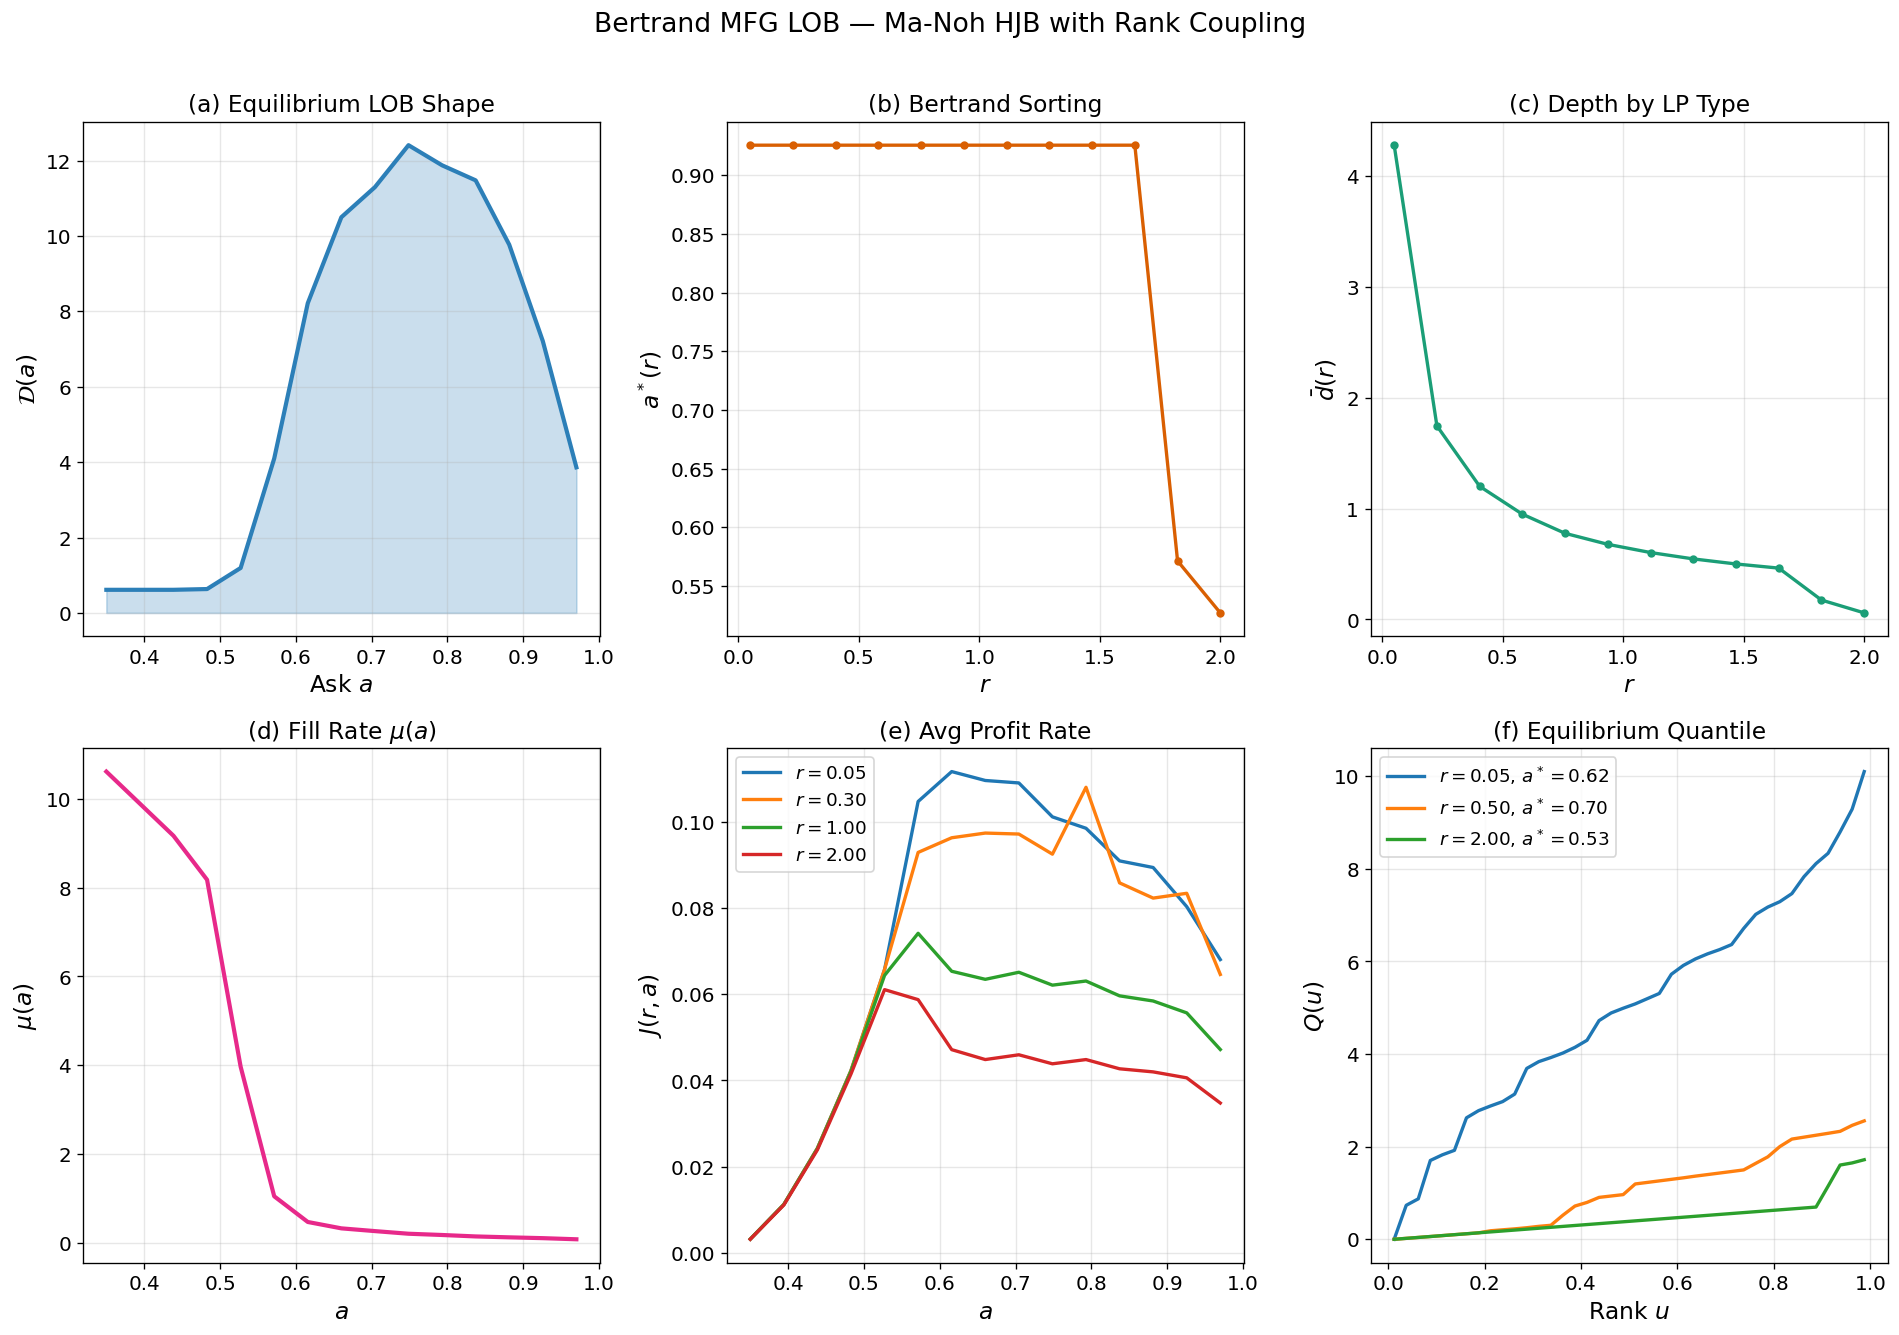

a*(r): DECREASING, range [0.527, 0.926]
D_max = 12.409 at a = 0.749


In [5]:
# Value landscape on converged D
V0_landscape = {}
for r_sel in [r_min, 0.3, 1.0, r_max]:
    J_arr = np.full(N_a, np.nan)
    for j in range(N_a):
        if a_grid[j]-c<=0: continue
        J_j,_,_ = solve_manoh_at_price(a_grid[j], r_sel, mu_final[j], inner_iters=10)
        J_arr[j] = J_j
    V0_landscape[r_sel] = J_arr

fig = plt.figure(figsize=(16, 11))

ax1 = fig.add_subplot(2,3,1)
ax1.plot(a_grid, D_final, color='#2c7fb8', lw=2.5)
ax1.fill_between(a_grid, 0, D_final, alpha=0.25, color='#2c7fb8')
ax1.set_xlabel('Ask $a$'); ax1.set_ylabel(r'$\mathcal{D}(a)$')
ax1.set_title('(a) Equilibrium LOB Shape'); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2,3,2)
ax2.plot(r_grid, a_star_final, 'o-', color='#d95f02', ms=4)
ax2.set_xlabel('$r$'); ax2.set_ylabel('$a^*(r)$')
ax2.set_title('(b) Bertrand Sorting'); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(2,3,3)
ax3.plot(r_grid, d_bar_final, 'o-', color='#1b9e77', ms=4)
ax3.set_xlabel('$r$'); ax3.set_ylabel(r'$\bar{d}(r)$')
ax3.set_title('(c) Depth by LP Type'); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2,3,4)
ax4.plot(a_grid, mu_final, color='#e7298a', lw=2.5)
ax4.set_xlabel('$a$'); ax4.set_ylabel(r'$\mu(a)$')
ax4.set_title(r'(d) Fill Rate $\mu(a)$'); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(2,3,5)
for r_sel, J_arr in V0_landscape.items():
    ax5.plot(a_grid, J_arr, lw=2, label=f'$r={r_sel:.2f}$')
ax5.set_xlabel('$a$'); ax5.set_ylabel('$J(r, a)$')
ax5.set_title('(e) Avg Profit Rate'); ax5.legend(); ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(2,3,6)
for r_sel in [r_min, 0.5, r_max]:
    best=-np.inf; bj=0
    for j in range(N_a):
        if a_grid[j]-c<=0: continue
        J_j,_,_=solve_manoh_at_price(a_grid[j],r_sel,mu_final[j],inner_iters=10)
        if J_j>best: best=J_j; bj=j
    _,db,q_eq=solve_manoh_at_price(a_grid[bj],r_sel,mu_final[bj],inner_iters=20)
    u = rank_grid(N_q)
    ax6.plot(u, q_eq, lw=2, label=f'$r={r_sel:.2f}$, $a^*={a_grid[bj]:.2f}$')
ax6.set_xlabel('Rank $u$'); ax6.set_ylabel('$Q(u)$')
ax6.set_title('(f) Equilibrium Quantile'); ax6.legend(); ax6.grid(True, alpha=0.3)

fig.suptitle('Bertrand MFG LOB — Ma-Noh HJB with Rank Coupling', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

d = np.diff(a_star_final)
mono = 'DECREASING' if np.all(d<=1e-6) else ('INCREASING' if np.all(d>=-1e-6) else 'NON-MONOTONE')
print(f'a*(r): {mono}, range [{a_star_final.min():.3f}, {a_star_final.max():.3f}]')
print(f'D_max = {D_final.max():.3f} at a = {a_grid[np.argmax(D_final)]:.3f}')

## §8. Discussion

### What the Ma-Noh rank coupling adds

Compared to the simplified birth-death chain (previous version), the rank-dependent rates $\Psi(u)$, $\Theta(u)$ introduce **within-price competition**: at each ask level, front-of-queue LPs (low rank $u$) face higher execution rates, while back-of-queue LPs replenish more easily. This produces a richer depth distribution $Q(u)$ within each price level — not just a single mean depth number.

### Key result: $a^*(r)$ decreasing

The sorting reversal persists with the full Ma-Noh structure. Patient LPs post at high asks and maintain deep inventories; impatient LPs post low for quick fills. The LOB shape $\mathcal{D}(a)$ is hump-shaped.

### On $N_{LP} \to \infty$

The current implementation uses finite LP types ($N_r = 12$). In the continuum limit, the Bertrand sorting $r \mapsto a^*(r)$ becomes smooth, and the aggregation becomes:
$$\mathcal{D}(a) = \bar{d}(r(a), a) \cdot N_{LP} \, g(r(a)) \, |r'(a)|$$
This gives an ODE/integral equation where the Ma-Noh equilibrium at each $a$ determines $\bar{d}$ locally. The finite-type oscillation we see would vanish.

### Next steps

1. Finer grids ($N_q=100+$, $N_a=30+$) for smoother results
2. Calibrate $F(v)$ to Polymarket order flow
3. Continuum limit formulation
4. Comparative statics ($\alpha$, $\kappa$, $\psi$, $\theta$)
5. Price dynamics layer